In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi

In [2]:
# parameters
rho = 1.0    # net local growth rate
mu = 2.0      # nomad attraction-to-departure ratio
sigma = 3.0   # purchasing power multiplier

# define RHS of the ODE
def f(u,t):
    dudt = np.zeros(2)
    x, y = u[0], u[1]
    if x + y == 0:
        dudt[0] = rho * x
        dudt[1] = -y
        return dudt
    dudt[0] = x * (rho - x - sigma * y)
    dudt[1] = y * (mu * x / (x + y) - 1)
    return dudt

# equilibrium values (derived by hand in the report)
x_star = rho / (1 + (mu - 1) * sigma)
y_star = (mu - 1) * rho / (1 + (mu - 1) * sigma)

## Phase Portrait

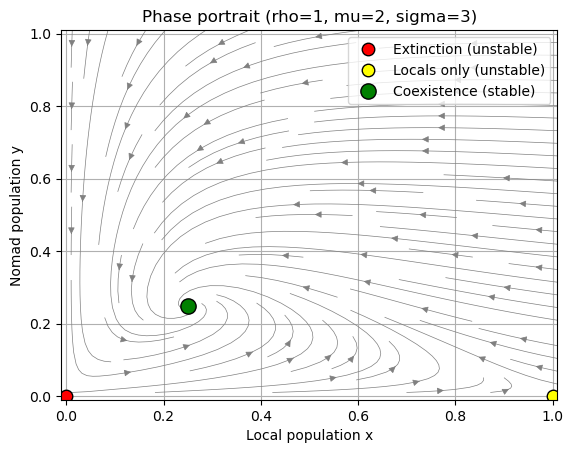

In [3]:
# vector field grid
xvals = np.linspace(0.01, 1.01, 25)
yvals = np.linspace(0.01, 1.01, 25)
X, Y = np.meshgrid(xvals, yvals)

DX = X * (rho - X - sigma * Y)
DY = Y * (mu * X / (X + Y) - 1)

# plot
plt.figure()
plt.streamplot(X, Y, DX, DY, color='grey', linewidth=0.5)

plt.plot(0, 0, 'o', color='red', markersize=9,
         markeredgecolor='black', label='Extinction (unstable)')
plt.plot(rho, 0, 'o', color='yellow', markersize=9,
         markeredgecolor='black', label='Locals only (unstable)')
plt.plot(x_star, y_star, 'o', color='green', markersize=11,
         markeredgecolor='black', label='Coexistence (stable)')

plt.xlabel('Local population x')
plt.ylabel('Nomad population y')
plt.title('Phase portrait (rho=1, mu=2, sigma=3)')
plt.legend(loc='upper right')
plt.xlim(-0.01, 1.01)
plt.ylim(-0.01, 1.01)
plt.grid()
plt.savefig('phase_portrait.png', dpi=200, bbox_inches='tight')
plt.show()

## Time Series

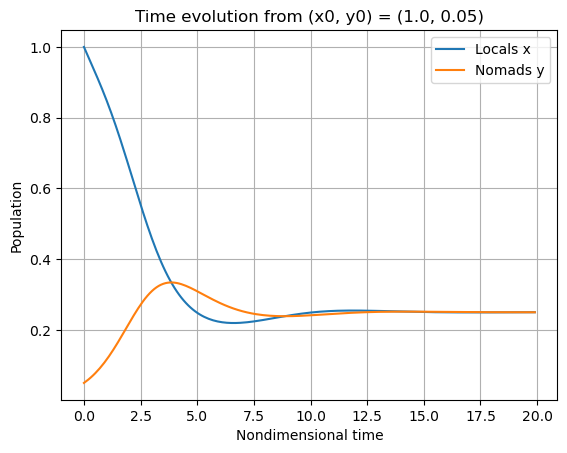

In [4]:
# parameters
tmax = 20
dt = 0.1

# initial condition: neighbourhood at local carrying capacity, small nomad population
u0 = [1.0, 0.05]

# set up time vector
t = np.arange(0, tmax, dt)

# integrate the ODEs
u = spi.odeint(f, u0, t)

# plot solution
plt.figure()
plt.plot(t, u[:,0], label='Locals x')
plt.plot(t, u[:,1], label='Nomads y')
plt.xlabel('Nondimensional time')
plt.ylabel('Population')
plt.title('Time evolution from (x0, y0) = (1.0, 0.05)')
plt.legend()
plt.grid()
plt.savefig('time_series.png', dpi=200, bbox_inches='tight')
plt.show()

/var/folders/8b/8xv60sm9601dqdzch7jd5lsr0000gn/T/ipykernel_62380/303967063.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dudt[0] = x * (rho - x - sigma * y)


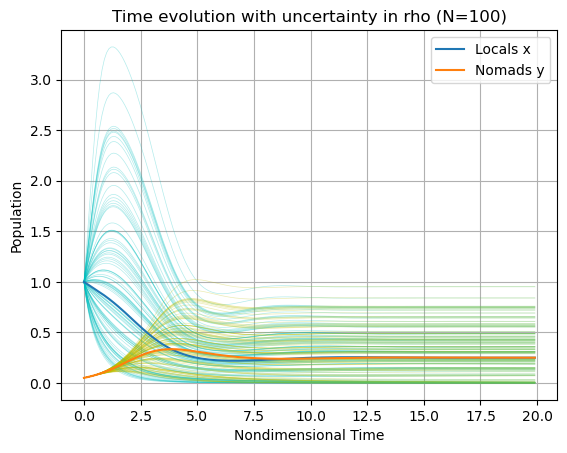

In [5]:
#Uncertainty analysis -- add in the noise to rho, mu, sigma 
N = 100
T_sols = []

for i in range(N):
    rho = 1.0 + np.random.normal(0, 1, 1)
    T = spi.odeint(f, u0,t)
    T_sols.append(T)
    plt.plot(t,T[:,0],'-c',alpha=0.3,linewidth=0.5)
    plt.plot(t,T[:,1],'-y',alpha=0.3,linewidth=0.5)
    
#convert T_sols to array to find mean -- python stores as list, need array
T_average = np.array(T_sols)

plt.plot(t, u[:,0], label='Locals x')
plt.plot(t, u[:,1], label='Nomads y')
plt.title("Time evolution with uncertainty in rho (N=100)")
plt.legend()
plt.grid(True)
plt.xlabel('Nondimensional Time')
plt.ylabel('Population')
plt.savefig('rho_uncertainty.png', dpi=200, bbox_inches='tight')
plt.show()

/var/folders/8b/8xv60sm9601dqdzch7jd5lsr0000gn/T/ipykernel_62380/303967063.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dudt[1] = y * (mu * x / (x + y) - 1)


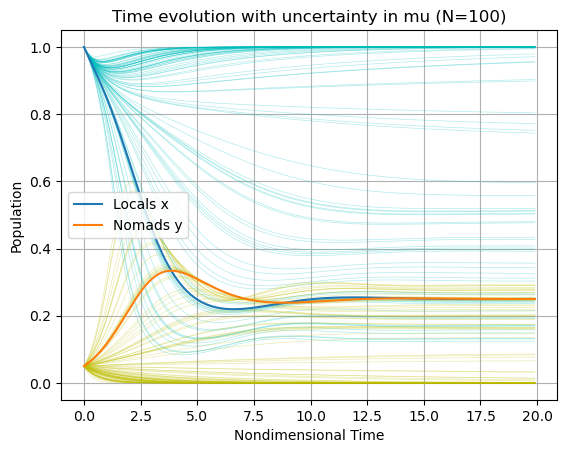

In [9]:
#Uncertainty analysis -- add in the noise to rho, mu, sigma 
N = 100
T_sols = []

rho = 1.0
sigma = 3.0

for i in range(N):
    mu = 1.0 + np.random.normal(0, 1, 1)
    T = spi.odeint(f, u0,t)
    T_sols.append(T)
    plt.plot(t,T[:, 0],'-c',alpha=0.3,linewidth=0.5)
    plt.plot(t,T[:, 1],'-y',alpha=0.3,linewidth=0.5)
    
#convert T_sols to array to find mean -- python stores as list, need array
T_average = np.array(T_sols)

plt.plot(t, u[:,0], label='Locals x')
plt.plot(t, u[:,1], label='Nomads y')
plt.title("Time evolution with uncertainty in mu (N=100)")
plt.grid(True)
plt.xlabel('Nondimensional Time')
plt.ylabel('Population')
plt.legend()
plt.savefig('mu_uncertainty.png', dpi=200, bbox_inches='tight')
plt.show()

/var/folders/8b/8xv60sm9601dqdzch7jd5lsr0000gn/T/ipykernel_62380/303967063.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dudt[0] = x * (rho - x - sigma * y)


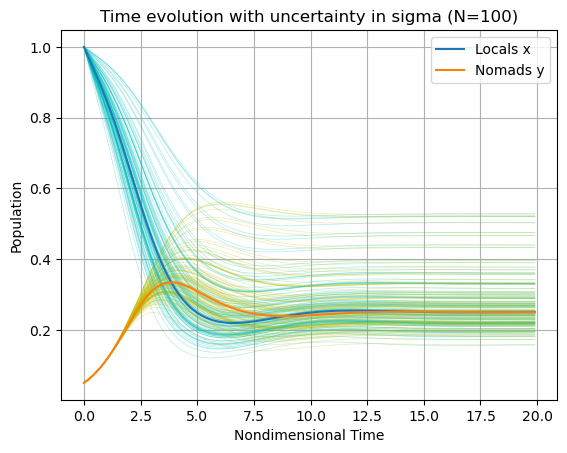

In [7]:
#Uncertainty analysis -- add in the noise to rho, mu, sigma 
N = 100
T_sols = []

rho = 1.0
mu = 2.0

for i in range(N):
    sigma = 3.0 + np.random.normal(0, 1, 1)
    T = spi.odeint(f, u0,t)
    T_sols.append(T)
    plt.plot(t,T[:,0],'-c',alpha=0.3,linewidth=0.5)
    plt.plot(t,T[:,1],'-y',alpha=0.3,linewidth=0.5)
    
#convert T_sols to array to find mean -- python stores as list, need array
T_average = np.array(T_sols)

plt.plot(t, u[:,0], label='Locals x')
plt.plot(t, u[:,1], label='Nomads y')
plt.legend()
plt.title("Time evolution with uncertainty in sigma (N=100)")
plt.grid(True)
plt.xlabel('Nondimensional Time')
plt.ylabel('Population')
plt.savefig('sigma_uncertainty.png', dpi=200, bbox_inches='tight')
plt.show()